# Exploração de Dados Públicos com Estatística Descritiva: Base de Dados da Carteira de Investimento do Ministério das Cidades

## Informações e Descrição sobre o Dataset

### **1. Escolha de um Dataset Público**

Para o desenvolvimento desta atividade, foi utilizado o portal oficial de dados abertos do Governo Brasileiro: http://dados.gov.br  
O portal disponibiliza bases públicas de diversas áreas, como educação, saúde, mobilidade, infraestrutura, economia e gestão pública, promovendo transparência e acesso à informação.

### **2. Descrição do Dataset**

#### 2.1 Nome do Dataset e Link Original

**Nome do Dataset:**  
`Base de Dados da Carteira de Investimento do Ministério das Cidades`

**Link Oficial no Portal de Dados Abertos:**  
https://dados.gov.br/dados/conjuntos-dados/base-de-dados-da-carteira-de-investimento-do-ministerio-das-cidades

**Área temática:**   
Investimentos públicos, desenvolvimento urbano, habitação e infraestrutura.  
Instrumentos administrativos de investimento: Contratos, Convênios, Termos de compromisso, Operações de repasse, Instrumentos financeiros entre União e estados/municípios

#### 2.2 Órgão Responsável

**Órgão Publicador:**  
Ministério das Cidades – Governo Federal do Brasil  
*O Ministério das Cidades é responsável por políticas públicas voltadas ao desenvolvimento urbano, habitação, saneamento e mobilidade urbana.*

#### 2.3 Descrição do Tema e Finalidade

Este conjunto de dados apresenta informações detalhadas sobre a carteira de investimentos do **Ministério das Cidades**, consolidando dados relacionados a:

- Programas governamentais

- Operações de financiamento

- Investimentos públicos

- Infraestrutura urbana

- Habitação social

A base foi construída a partir de fontes oficiais, como:

`Transferegov`

`BD Gestores`

`Canal FGTS`

`Minha Casa Minha Vida`

`BNDES`

**Finalidade da Base:**  

A disponibilização do dataset tem como objetivo:

- Promover transparência pública

- Facilitar o acompanhamento das políticas públicas

- Apoiar ações de fiscalização e controle social

- Permitir análises estatísticas e econômicas sobre investimentos federais

## Desenvolvimento da atividade

In [293]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown


sns.set_theme(style="whitegrid")

In [294]:

"""
Atividade 2.4
Determinar o número de registros e colunas do dataset.
Tratamento de encoding e leitura completa do arquivo.
"""

CAMINHO_CSV = Path("./carteira_investimento_mcid.csv")

if not CAMINHO_CSV.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {CAMINHO_CSV.resolve()}\n"
        "Coloque o CSV na mesma pasta do notebook ou ajuste CAMINHO_CSV."
    )

df = pd.read_csv(
    CAMINHO_CSV,
    encoding="latin1",
    sep=";",
    low_memory=False
)

df.shape

(132182, 72)

In [295]:

"""
Diagnóstico e conversão:
Identifica colunas 'object' que parecem numéricas (ex: '1.234,56') e converte.
Evita perder colunas financeiras em análises quantitativas.
"""

def tenta_converter_numero_br(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    # Remove strings vazias / 'nan'
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})

    # Remove separador de milhar '.' e troca decimal ',' por '.'
    s = s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)

    return pd.to_numeric(s, errors="coerce")

colunas_obj = df.select_dtypes(include=["object", "string"]).columns.tolist()

convertidas = []
for col in colunas_obj:
    convertido = tenta_converter_numero_br(df[col])
    # Heurística: se converteu uma fração relevante de valores, adota
    taxa_convertida = convertido.notna().mean()
    if taxa_convertida >= 0.60:  # ajuste se necessário
        df[col] = convertido
        convertidas.append((col, round(taxa_convertida*100, 2)))

convertidas[:20], len(convertidas)

([('num_convenio', np.float64(75.53)),
  ('cod_operacao', np.float64(98.84)),
  ('cod_dv', np.float64(98.85)),
  ('cod_contrato', np.float64(99.21)),
  ('cod_ibge_7dig', np.float64(99.99)),
  ('cod_tomador', np.float64(98.15)),
  ('cnpj_agente_financeiro', np.float64(99.87)),
  ('vlr_investimento', np.float64(99.98)),
  ('vlr_repasse', np.float64(99.98)),
  ('vlr_contrapartida', np.float64(99.98)),
  ('vlr_empenhado', np.float64(99.99)),
  ('vlr_desembolsado', np.float64(99.99)),
  ('vlr_desbloqueado', np.float64(99.99)),
  ('vlr_pago', np.float64(99.99)),
  ('vlr_taxa_adm', np.float64(99.99)),
  ('prc_execucao_fisica', np.float64(99.8))],
 16)

#### Conversão de colunas numéricas armazenadas como texto

Durante a análise, foi identificado que algumas colunas financeiras estavam armazenadas como texto, o que impediria cálculos estatísticos corretos.
Após a conversão para formato numérico, foi possível incluir essas variáveis nas análises de média, mediana e dispersão.
Esse passo foi essencial para garantir que os resultados representassem corretamente os valores financeiros reais dos instrumentos.

In [296]:
"""
Atividade 2.4
Apresentar número de registros e colunas em formato de tabela.
"""

linhas, colunas = df.shape

resumo_dimensoes = pd.DataFrame({
    "Descrição": ["Número de Registros (Linhas)", "Número de Colunas"],
    "Valor": [linhas, colunas]
})

resumo_dimensoes

,Descrição,Valor
0,Número de Registros (Linhas),132182
1,Número de Colunas,72


In [297]:
"""
Atividade 2.4
Listar tipos de dados e quantidade de valores não nulos em formato tabular.
"""

tipos_dados = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo de Dado": df.dtypes.values,
    "Valores Não Nulos": df.notnull().sum().values,
    "Valores Nulos": df.isnull().sum().values
})

tipos_dados.head(20)

,Coluna,Tipo de Dado,Valores Não Nulos,Valores Nulos
0,cod_tci,str,132182,0
1,num_convenio,float64,99833,32349
2,cod_proposta,str,132177,5
3,num_proposta,str,132177,5
4,cod_operacao,float64,130655,1527
5,cod_dv,float64,130658,1524
6,cod_contrato,float64,131136,1046
7,cod_saci,str,2166,130016
8,cod_ag_operador,str,132177,5
9,cod_ag_financeiro,str,132177,5


In [298]:
"""
Atividade 2.5
Significado de algumas variáveis importantes do dataset.
"""

variaveis_importantes = pd.DataFrame({
    "Variável": [
        "cod_tci",
        "num_convenio",
        "cod_proposta",
        "num_ano_instrumento",
        "qtd_emendas",
        "txt_uf",
        "txt_regiao",
        "cod_ibge_6dig"
    ],
    "Descrição": [
        "Código identificador da operação no TCI",
        "Número do convênio firmado",
        "Código da proposta cadastrada",
        "O ano em que o instrumento (contrato/convênio) foi formalizado.",
        "Recurso direcionado por deputados ou senadores ao orçamento público.",
        "Unidade da Federação (Estado)",
        "Região geográfica do Brasil",
        "Código IBGE do município"
    ]
})

variaveis_importantes.style.set_properties(**{
    "text-align": "left"
})

,Variável,Descrição
0,cod_tci,Código identificador da operação no TCI
1,num_convenio,Número do convênio firmado
2,cod_proposta,Código da proposta cadastrada
3,num_ano_instrumento,O ano em que o instrumento (contrato/convênio) foi formalizado.
4,qtd_emendas,Recurso direcionado por deputados ou senadores ao orçamento público.
5,txt_uf,Unidade da Federação (Estado)
6,txt_regiao,Região geográfica do Brasil
7,cod_ibge_6dig,Código IBGE do município


#### Considerações sobre a Estrutura do Dataset

A base analisada possui **132.182 registros e 72 colunas**, caracterizando-se como um dataset amplo e consolidado. Observa-se que diversas variáveis representam identificadores administrativos, códigos e campos descritivos, enquanto outras correspondem a indicadores quantitativos e datas.

Foi identificada a presença de **valores ausentes em algumas colunas**, o que sugere heterogeneidade no preenchimento das informações, possivelmente decorrente da integração de múltiplas fontes oficiais. A estrutura indica que a base foi organizada como uma tabela consolidada (flat table), não totalmente normalizada, reunindo diferentes naturezas de dados em um único conjunto.

In [299]:
"""
Atividade 3.1
Selecionar variáveis quantitativas com checagens e remoções
"""

numericas = df.select_dtypes(include=[np.number]).copy()

# colunas a excluir por serem identificadores / datas / especiais
colunas_remover = [
    "cod_ibge_6dig",
    "dte_paralisacao",
    "num_ano_instrumento"
]

numericas = numericas.drop(columns=[c for c in colunas_remover if c in numericas.columns], errors="ignore")

# Remover colunas totalmente nulas
numericas = numericas.dropna(axis=1, how="all")

# Remover colunas com variância zero (ou std NaN por falta de dados)
stds = numericas.std(numeric_only=True)
numericas = numericas.loc[:, stds.fillna(0) > 0]

numericas.columns, numericas.shape

(Index(['num_convenio', 'cod_operacao', 'cod_dv', 'cod_contrato',
        'cod_ibge_7dig', 'qtd_emendas', 'cod_tomador', 'cnpj_agente_financeiro',
        'vlr_investimento', 'vlr_repasse', 'vlr_contrapartida', 'vlr_empenhado',
        'vlr_desembolsado', 'vlr_desbloqueado', 'vlr_pago',
        'prc_execucao_fisica'],
       dtype='str'),
 (132182, 16))

In [300]:
"""
Atividade 3.1
Calcular média, mediana e moda com tratamento de casos vazios.
"""

if numericas.shape[1] == 0:
    raise ValueError(
        "Nenhuma coluna numérica válida encontrada em 'numericas'.\n"
        "Verifique se as colunas numéricas vieram como texto e se a conversão foi aplicada."
    )

moda = numericas.mode(dropna=True)
moda_1a = moda.iloc[0] if not moda.empty else pd.Series([np.nan]*numericas.shape[1], index=numericas.columns)

estatisticas_central = pd.DataFrame({
    "Média": numericas.mean(),
    "Mediana": numericas.median(),
    "Moda": moda_1a
}).round(2)

estatisticas_central

,Média,Mediana,Moda
num_convenio,6.225201e+05,6.684490e+05,0.000000e+00
cod_operacao,4.541960e+05,2.498420e+05,2.495720e+05
cod_dv,4.955000e+01,5.000000e+01,5.900000e+01
cod_contrato,1.602699e+10,2.500069e+07,2.495727e+07
cod_ibge_7dig,3.274646e+06,3.167608e+06,1.400605e+06
qtd_emendas,1.000000e+00,1.000000e+00,1.000000e+00
cod_tomador,3.161207e+13,1.802883e+13,8.793468e+13
cnpj_agente_financeiro,8.626259e+11,3.603050e+11,3.603050e+11
vlr_investimento,3.760874e+06,2.550000e+05,0.000000e+00
vlr_repasse,2.717033e+06,2.388560e+05,1.000000e+05


In [301]:

"""
Atividade 3.1 Resultados Parciais
"""

# Garantir que numericas existe
if "numericas" not in globals():
    raise ValueError("A variável 'numericas' não está definida. Execute a célula que a cria primeiro.")

# Recalcular dispersão aqui para evitar NameError
dispersao = pd.DataFrame({
    "Desvio Padrão": numericas.std(numeric_only=True),
    "Variância": numericas.var(numeric_only=True)
})

# Top 5 variáveis mais dispersas
top_variabilidade = dispersao["Desvio Padrão"].sort_values(ascending=False).head(5)

# Top 5 mais assimétricas
top_assimetria = (
    numericas.skew(numeric_only=True)
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

texto_variabilidade = "\n".join(
    [f"- **{col}**: {valor:.2f}" for col, valor in top_variabilidade.items()]
)

texto_assimetria = "\n".join(
    [f"- **{col}**: {valor:.2f}" for col, valor in top_assimetria.items()]
)

md = f"""
### Interpretação das estatísticas

#### Variáveis com maior variabilidade (Desvio Padrão)
{texto_variabilidade}  
Os três primeiros (cod_tomador, cnpj_agente_financeiro, cod_contrato) são códigos/identificadores. Eles aparecem com números muito grandes, mas isso não significa “projeto maior” significa apenas que são IDs longos e variados.
Já vlr_investimento e vlr_repasse são valores financeiros. Existem projetos com valores muito diferentes entre si, ou seja, projetos pequenos e projetos muito grandes na mesma base.

#### Variáveis com maior assimetria absoluta (|skew|)
{texto_assimetria}  
A maioria dos contratos tem valores menores, mas existe um grupo pequeno com valores muito altos, que influencia o comportamento da variável.
---

### Leitura técnica aplicada à base:

- Variáveis com alto desvio padrão indicam grande heterogeneidade nos valores observados.
- Variáveis com alta assimetria indicam concentração de valores baixos com presença de valores extremos elevados.
- Em bases de investimento público, esse comportamento é esperado devido à diferença de porte entre projetos.

"""

display(Markdown(md))


### Interpretação das estatísticas

#### Variáveis com maior variabilidade (Desvio Padrão)
- **cod_tomador**: 30290608164397.13
- **cnpj_agente_financeiro**: 5383003378509.37
- **cod_contrato**: 369487879704.87
- **vlr_investimento**: 71539167.64
- **vlr_repasse**: 45995896.51  
Os três primeiros (cod_tomador, cnpj_agente_financeiro, cod_contrato) são códigos/identificadores. Eles aparecem com números muito grandes, mas isso não significa “projeto maior” significa apenas que são IDs longos e variados.
Já vlr_investimento e vlr_repasse são valores financeiros. Existem projetos com valores muito diferentes entre si, ou seja, projetos pequenos e projetos muito grandes na mesma base.

#### Variáveis com maior assimetria absoluta (|skew|)
- **vlr_contrapartida**: 158.97
- **vlr_repasse**: 136.71
- **vlr_investimento**: 117.37
- **vlr_desbloqueado**: 88.59
- **vlr_empenhado**: 75.80  
A maioria dos contratos tem valores menores, mas existe um grupo pequeno com valores muito altos, que influencia o comportamento da variável.
---

### Leitura técnica aplicada à base:

- Variáveis com alto desvio padrão indicam grande heterogeneidade nos valores observados.
- Variáveis com alta assimetria indicam concentração de valores baixos com presença de valores extremos elevados.
- Em bases de investimento público, esse comportamento é esperado devido à diferença de porte entre projetos.



In [302]:
"""
Atividade 3.2
Calcular valores mínimo e máximo das variáveis quantitativas.
"""

min_max = pd.DataFrame({
    "Mínimo": numericas.min(),
    "Máximo": numericas.max()
})

min_max

,Mínimo,Máximo
num_convenio,0.000000e+00,9.923280e+05
cod_operacao,1.256000e+03,6.100279e+06
cod_dv,0.000000e+00,9.900000e+01
cod_contrato,0.000000e+00,1.420424e+13
cod_ibge_7dig,1.100015e+06,5.300108e+06
qtd_emendas,0.000000e+00,6.000000e+00
cod_tomador,7.290002e+08,1.000000e+14
cnpj_agente_financeiro,0.000000e+00,9.281656e+13
vlr_investimento,0.000000e+00,1.443760e+10
vlr_repasse,0.000000e+00,1.051140e+10


In [303]:
"""
Atividade 3.3
Calcular desvio padrão e variância das variáveis quantitativas.
"""

dispersao = pd.DataFrame({
    "Desvio Padrão": numericas.std(),
    "Variância": numericas.var()
})

dispersao.round(2)

,Desvio Padrão,Variância
num_convenio,2.937183e+05,8.627044e+10
cod_operacao,4.188712e+05,1.754531e+11
cod_dv,2.886000e+01,8.327900e+02
cod_contrato,3.694879e+11,1.365213e+23
cod_ibge_7dig,1.002388e+06,1.004783e+12
qtd_emendas,1.000000e-01,1.000000e-02
cod_tomador,3.029061e+13,9.175209e+26
cnpj_agente_financeiro,5.383003e+12,2.897673e+25
vlr_investimento,7.153917e+07,5.117853e+15
vlr_repasse,4.599590e+07,2.115622e+15


In [304]:
"""
Atividade 3.4
Calcular quartis e intervalo interquartil (IQR).
"""

q1 = numericas.quantile(0.25)
q2 = numericas.quantile(0.50)
q3 = numericas.quantile(0.75)
iqr = q3 - q1

quartis = pd.DataFrame({
    "Q1 (25%)": q1,
    "Mediana (Q2)": q2,
    "Q3 (75%)": q3,
    "IQR": iqr
})

quartis.round(2)

,Q1 (25%),Mediana (Q2),Q3 (75%),IQR
num_convenio,4.928580e+05,6.684490e+05,8.471740e+05,3.543160e+05
cod_operacao,1.190045e+05,2.498420e+05,1.025636e+06,9.066320e+05
cod_dv,2.500000e+01,5.000000e+01,7.400000e+01,4.900000e+01
cod_contrato,1.190770e+07,2.500069e+07,1.025957e+08,9.068796e+07
cod_ibge_7dig,2.514701e+06,3.167608e+06,4.125308e+06,1.610607e+06
qtd_emendas,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
cod_tomador,7.744303e+12,1.802883e+13,4.657851e+13,3.883421e+13
cnpj_agente_financeiro,3.603050e+11,3.603050e+11,3.603050e+11,0.000000e+00
vlr_investimento,1.100000e+05,2.550000e+05,5.876371e+05,4.776371e+05
vlr_repasse,9.820000e+04,2.388560e+05,4.931000e+05,3.949000e+05


In [305]:
"""
Atividade 3.5
Contar valores ausentes e listar tipos de dados.
"""

resumo_dados = pd.DataFrame({
    "Tipo de Dado": df.dtypes,
    "Valores Não Nulos": df.notnull().sum(),
    "Valores Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100)
})

resumo_dados.sort_values(by="Valores Nulos", ascending=False).round(2)

,Tipo de Dado,Valores Não Nulos,Valores Nulos,% Nulos
dte_paralisacao,float64,0,132182,100.00
cod_saci,str,2166,130016,98.36
qtd_emendas,float64,25839,106343,80.45
dte_atualizacao_situacao_atual,str,36405,95777,72.46
dte_inicio_obra,str,42699,89483,67.70
...,...,...,...,...
txt_municipio,str,132177,5,0.00
cod_mdr_antigo,str,132177,5,0.00
cod_ag_financeiro,str,132177,5,0.00
bln_carga_legado_tci,str,132177,5,0.00


#### Análise de valores ausentes

A análise mostrou que algumas variáveis apresentam alta quantidade de valores ausentes.
Por exemplo, variáveis relacionadas à execução financeira apresentam maior incidência de valores ausentes, o que pode indicar instrumentos ainda não executados ou ausência de atualização no sistema.

#### Interpretação das Estatísticas Descritivas

Ao analisar os valores financeiros (como `vlr_investimento, vlr_repasse e vlr_contrapartida`), observou-se que:

- Existem registros com valor mínimo igual a zero, indicando instrumentos sem execução financeira registrada.
- A diferença entre os quartis (Q1, mediana e Q3) mostra grande variação entre os projetos.
  
Isso significa que a base contém tanto projetos de pequeno porte quanto projetos com valores muito maiores, o que explica a grande dispersão observada.

Na variável `prc_execucao_fisica`, a mediana e o terceiro quartil são iguais a 100%, indicando que a maior parte dos instrumentos está registrada como totalmente executada. Porém, a presença de valores iguais a 0% indica que há instrumentos não iniciados ou com informação incompleta. Isso indica que mais da metade dos instrumentos está registrada como totalmente executada, o que pode indicar conclusão formal do projeto ou registro administrativo padronizado.

Esses resultados mostram que o conjunto de dados é heterogêneo e contém diferentes estágios de execução. Observa-se, por exemplo, que a diferença entre o primeiro quartil (Q1) e o terceiro quartil (Q3) nas variáveis financeiras é elevada, indicando que há grande variação entre os valores dos projetos.

In [306]:
"""
Atividade 3.5
Calcular percentual geral de valores ausentes na base.
"""

percentual_geral_nulos = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100

round(percentual_geral_nulos, 2)

np.float64(7.89)

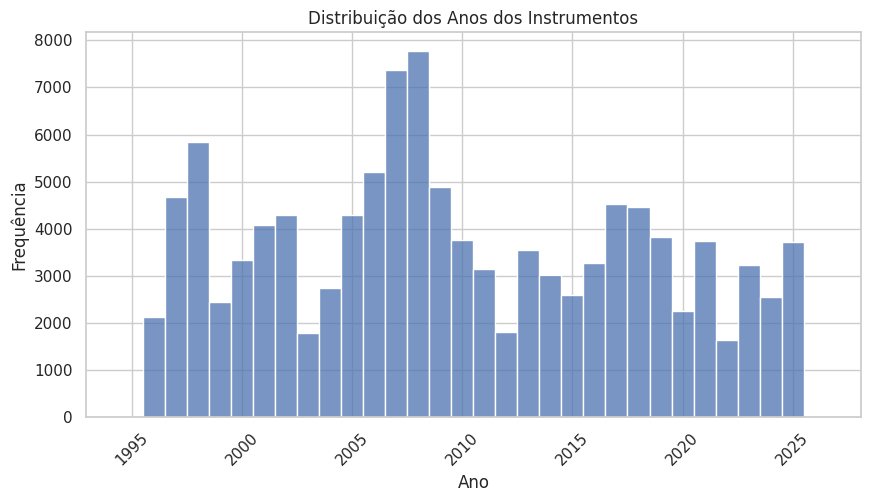

(111998, 132182, 84.73)

In [307]:
"""
Atividade 3.6
Gerar histograma da variável num_ano_instrumento.
"""

col_ano = "num_ano_instrumento"
if col_ano not in df.columns:
    raise KeyError(f"Coluna '{col_ano}' não encontrada no dataset.")

anos = pd.to_numeric(df[col_ano], errors="coerce")

# Filtra anos plausíveis (ajuste se necessário)
ano_min = 1990
ano_max = pd.Timestamp.today().year + 1
anos_validos = anos[(anos >= ano_min) & (anos <= ano_max)]

plt.figure(figsize=(10,5))
sns.histplot(anos_validos, binwidth=1, discrete=True)
plt.title("Distribuição dos Anos dos Instrumentos")
plt.xlabel("Ano")
plt.ylabel("Frequência")
plt.xticks(rotation=45)
plt.show()

len(anos_validos), len(df), round(len(anos_validos)/len(df)*100, 2)

#### Observação sobre o gráfico de anos

Para montar o histograma, foram considerados apenas anos plausíveis (ex.: entre 1990 e o próximo ano).
Isso evita distorções causadas por valores como ano = 0 ou anos fora da realidade, que geralmente indicam erro de preenchimento.  
Após aplicar esse filtro, ficaram 111.998 registros de um total de 132.182, ou seja, 84,73% da base.

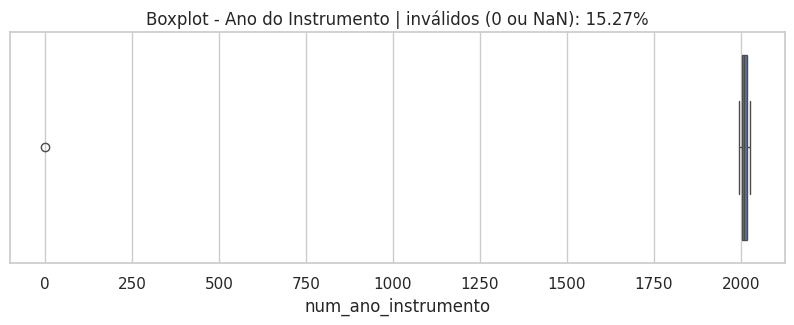

15.27

In [308]:
"""
Atividade 3.6
Gerar boxplot para identificar possíveis outliers no ano do instrumento.
"""

anos_num = pd.to_numeric(df["num_ano_instrumento"], errors="coerce")

invalidos = anos_num[(anos_num.isna()) | (anos_num == 0)]
pct_invalidos = round(len(invalidos)/len(df)*100, 2)

plt.figure(figsize=(10,3))
sns.boxplot(x=anos_num.dropna())
plt.title(f"Boxplot - Ano do Instrumento | inválidos (0 ou NaN): {pct_invalidos}%")
plt.show()

pct_invalidos

#### Análise do ano do instrumento

A distribuição dos anos mostrou maior concentração de registros entre 2003 e 2017, indicando que nesse período houve maior formalização de instrumentos.
No histograma observa-se maior frequência de registros nesse intervalo, com redução gradual após 2017.
Também foram identificados registros com ano igual a zero, o que sugere possível ausência de informação ou erro de preenchimento.
Essa concentração temporal pode estar relacionada a períodos de maior investimento público ou reorganização administrativa.

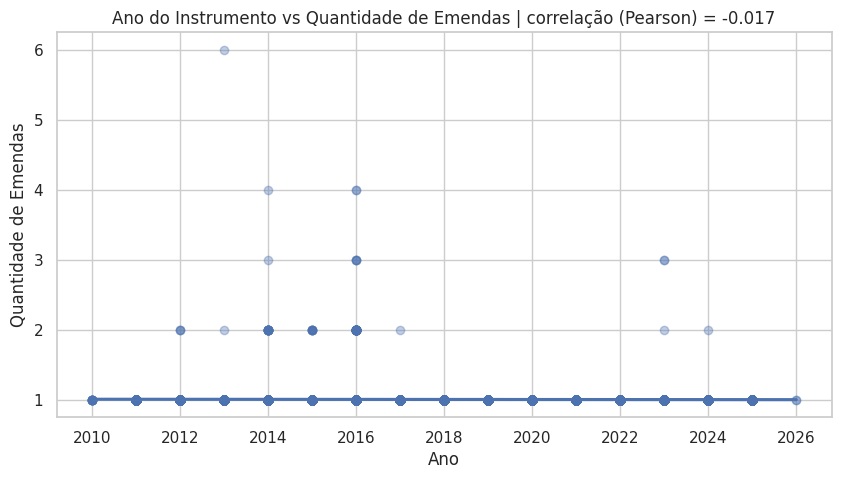

np.float64(-0.016684389368937916)

In [309]:
"""
Atividade 3.6
Dispersão entre ano e quantidade de emendas com remoção de valores nulos.
"""

cols = ["num_ano_instrumento", "qtd_emendas"]
for c in cols:
    if c not in df.columns:
        raise KeyError(f"Coluna '{c}' não encontrada no dataset.")

dados_plot = df[cols].copy()
dados_plot["num_ano_instrumento"] = pd.to_numeric(dados_plot["num_ano_instrumento"], errors="coerce")
dados_plot["qtd_emendas"] = pd.to_numeric(dados_plot["qtd_emendas"], errors="coerce")
dados_plot = dados_plot.dropna()

corr = dados_plot.corr(numeric_only=True).iloc[0,1]

plt.figure(figsize=(10,5))
sns.regplot(
    data=dados_plot,
    x="num_ano_instrumento",
    y="qtd_emendas",
    scatter_kws={"alpha": 0.35}
)
plt.title(f"Ano do Instrumento vs Quantidade de Emendas | correlação (Pearson) = {corr:.3f}")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Emendas")
plt.show()

corr

#### Relação entre ano e quantidade de emendas

A correlação de Pearson calculada foi de aproximadamente **-0.0167**.

Esse valor está extremamente próximo de zero, indicando que **não há relação linear significativa** entre o ano do instrumento e a quantidade de emendas.

Pelos dados, o número de emendas não cresce nem diminui de forma constante ao longo do tempo; emendas podem ocorrer em qualquer ano, dependendo do tipo de instrumento e do contexto do projeto.

In [310]:
"""
Atividade 3.7
Verificar proporção de anos inválidos (igual a zero).
"""

anos = pd.to_numeric(df["num_ano_instrumento"], errors="coerce")

ano_min = 1990
ano_max = pd.Timestamp.today().year + 1

qtd_zero = (anos == 0).sum()
qtd_nan = anos.isna().sum()
qtd_fora_intervalo = ((anos < ano_min) | (anos > ano_max)).sum()

resumo_anos = pd.DataFrame({
    "Tipo de problema": ["Ano = 0", "Ano ausente (NaN)", "Fora do intervalo plausível"],
    "Quantidade": [qtd_zero, qtd_nan, qtd_fora_intervalo],
    "% do dataset": [
        round(qtd_zero/len(df)*100, 2),
        round(qtd_nan/len(df)*100, 2),
        round(qtd_fora_intervalo/len(df)*100, 2)
    ]
})

resumo_anos

,Tipo de problema,Quantidade,% do dataset
0,Ano = 0,1,0.00
1,Ano ausente (NaN),20183,15.27
2,Fora do intervalo plausível,1,0.00


#### Síntese da Exploração Estatística

A análise estatística permitiu identificar padrões relevantes na base de dados. Algumas variáveis apresentaram alta concentração de valores nulos, indicando limitações no preenchimento ou aplicabilidade restrita a determinados tipos de operação.

A variável relacionada ao **ano do instrumento** mostrou concentração significativa entre **2003 e 2017**, com presença de valores inconsistentes (como ano igual a zero), sugerindo possível utilização de valor padrão para ausência de informação.

Também foi observado que determinadas colunas não apresentam variabilidade estatística, indicando ausência de dados efetivos. A filtragem criteriosa das variáveis quantitativas foi necessária para evitar distorções analíticas decorrentes de códigos administrativos tratados como números.

## Conclusão Geral

A análise exploratória mostrou que a base reúne instrumentos de investimento com perfis muito diferentes. Isso aparece claramente na variação dos valores financeiros, onde existem contratos de valores relativamente baixos e outros muito altos.

Também foi observada uma concentração forte de `execução física em 100%`. Isso não é “uma impressão”: nos quartis, 25% já é 100 e a mediana também é 100, indicando que `pelo menos metade dos registros` está marcada como execução total. 

Na dimensão temporal, houve maior `concentração de instrumentos entre 2003 e 2017`, e o gráfico de anos foi construído com filtro de plausibilidade para evitar distorções (por exemplo, ano = 0). Após o filtro, 84,73% dos registros permaneceram (111.998 de 132.182). 

Por fim, ao comparar ano com quantidade de emendas, a correlação foi -0.0167, ou seja, `não existe uma tendência linear clara` de aumento ou redução de emendas ao longo do tempo. 

Em resumo: a base tem potencial para análises públicas (distribuição temporal, padrões de execução, perfil financeiro), mas exige cuidados com inconsistências (ex.: anos inválidos e campos ausentes) antes de conclusões mais profundas.